### This notebook shows implementation of cross-entropy loss and usage of gradient descent

#### sources
 - PRML Section 4.3
 - StatQuest: CrossEntropy for neural network


In [1]:
#importing necessary files
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#generating random data 
np.random.seed(42)
n_samples = 200
n_features = 2

X = np.random.randn(n_samples, n_features)

w_true = np.array([2.0, -1.0])
b_true = 0.5
Z = X @ w_true + b_true

In [3]:
#sigmoid function 
def sigmoid(z):
    """Compute the sigmoid function"""
    return 1 / (1 + np.exp(-z))

# Probabilities
p = sigmoid(Z)

# Sample labels from probabilities
y = (np.random.rand(n_samples) < p).astype(int)

L(w,b)=(i=1)∏(N)​pi^yi​​(1−pi​)^1−yi​ -> likelihood function 

In [4]:
#log likehood function
def log_likelihood(y_true, p_pred):
    eps = 1e-15
    p_pred = np.clip(p_pred, eps, 1 - eps)
    return np.sum(y_true * np.log(p_pred) + (1 - y_true) * np.log(1 - p_pred))

print("log-likelihood:", log_likelihood(y, p))

log-likelihood: -84.57794445012134


In [5]:
#Cross-Entropy loss function
def cross_entropy_loss(y_true, p_pred):
    eps = 1e-15
    p_pred = np.clip(p_pred, eps, 1 - eps)
    return -np.mean(y_true*np.log(p_pred) + (1-y_true)*np.log(1-p_pred))

print("Initial Loss:", cross_entropy_loss(y, p))

Initial Loss: 0.42288972225060667


In [6]:
#initializing parameters
w = np.zeros(n_features)
b = 0

lr = 0.1
epochs = 1000

#gradient descent training 
loss_hist = []

for i in range(epochs):
    Z = X@ w + b
    p = sigmoid(Z)

    loss = cross_entropy_loss(y, p)
    loss_hist.append(loss)
     # Gradients
    dw = (1/n_samples) * (X.T @ (p - y))
    db = (1/n_samples) * np.sum(p - y)
    
    # Update
    w -= lr * dw
    b -= lr * db
    
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471805599452
Epoch 100, Loss: 0.4525223075613495
Epoch 200, Loss: 0.42936499857498034
Epoch 300, Loss: 0.42330479398998433
Epoch 400, Loss: 0.4212301015785817
Epoch 500, Loss: 0.42042812418708125
Epoch 600, Loss: 0.42009701046682685
Epoch 700, Loss: 0.41995486130504206
Epoch 800, Loss: 0.4198923339975555
Epoch 900, Loss: 0.4198643974764586


In [7]:
#final params
print("Trained weights:", w)
print("Trained bias:", b)

Trained weights: [ 2.17818343 -1.03475827]
Trained bias: 0.7040655755972257


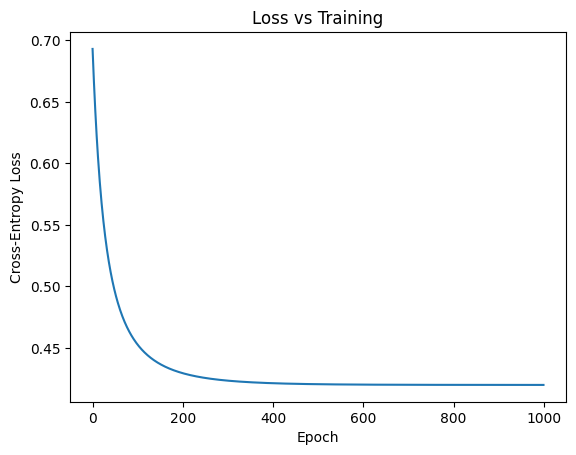

In [8]:
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss vs Training")
plt.show()

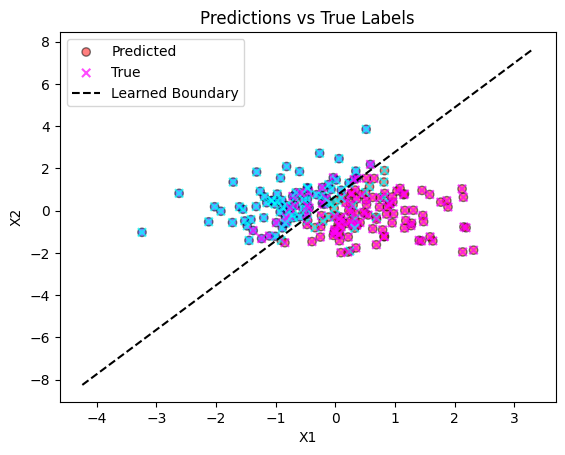

In [9]:
#post training predictions 
Z = X @ w + b
p = sigmoid(Z)

threshold = 0.5
y_pred = (p >= threshold).astype(int)

plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='bwr', edgecolor='k', alpha=0.5, label='Predicted')
plt.scatter(X[:,0], X[:,1], c=y, cmap='cool', marker='x', alpha=0.7, label='True')

x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_vals = -(w[0]*x1_vals + b)/w[1]

plt.plot(x1_vals, x2_vals, 'k--', label='Learned Boundary')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Predictions vs True Labels")
plt.show()

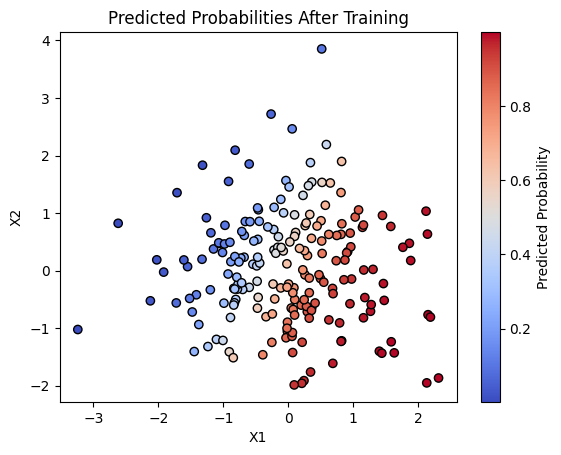

In [10]:
plt.scatter(X[:,0], X[:,1], c=p, cmap='coolwarm', edgecolor='k')
plt.colorbar(label='Predicted Probability')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Predicted Probabilities After Training")
plt.show()